In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [4]:
df = pd.read_csv("../data/energy_data.csv")

df.columns = df.columns.str.strip()

df[df.columns[0]] = pd.to_datetime(df[df.columns[0]])
df.set_index(df.columns[0], inplace=True)

df.head()

,fridge,ac,lights,microwave,total_power
timestamp,,,,,
2023-01-01 00:00:00,119,0,73,0,192
2023-01-01 01:00:00,134,0,0,0,134
2023-01-01 02:00:00,0,1551,73,0,1624
2023-01-01 03:00:00,0,0,66,0,66
2023-01-01 04:00:00,83,0,86,0,169


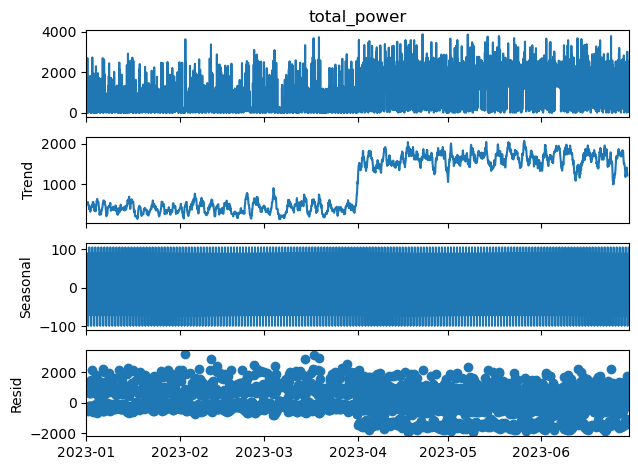

In [5]:
result = seasonal_decompose(df['total_power'], 
                            model='additive', 
                            period=24)

result.plot()
plt.show()

In [6]:
print("Trend Mean:", result.trend.mean())
print("Trend Standard Deviation:", result.trend.std())

Trend Mean: 1015.8794604763011
Trend Standard Deviation: 631.3317728421991


In [7]:
print("Residual Variance:", result.resid.var())

Residual Variance: 549738.0163451112


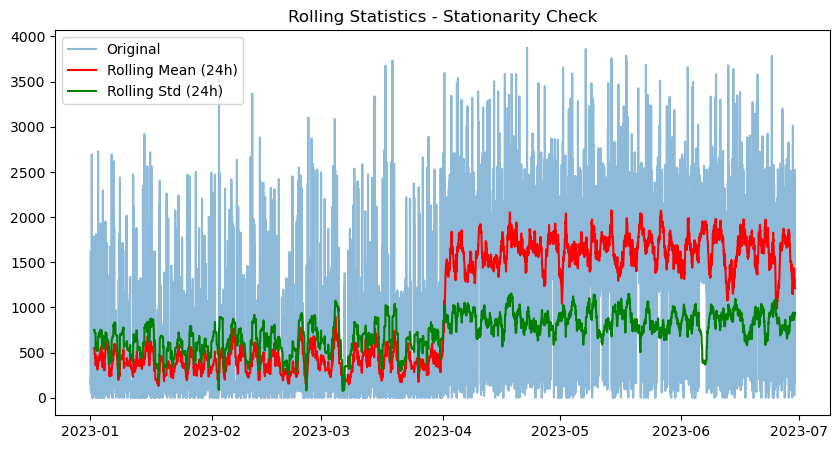

In [8]:
rolling_mean = df['total_power'].rolling(window=24).mean()
rolling_std = df['total_power'].rolling(window=24).std()

plt.figure(figsize=(10,5))
plt.plot(df['total_power'], label='Original', alpha=0.5)
plt.plot(rolling_mean, label='Rolling Mean (24h)', color='red')
plt.plot(rolling_std, label='Rolling Std (24h)', color='green')
plt.legend()
plt.title("Rolling Statistics - Stationarity Check")
plt.show()

Peak Consumption Hour: 23


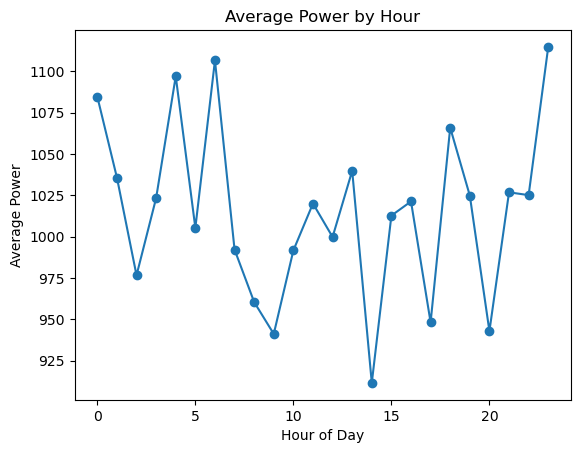

In [9]:
df['hour'] = df.index.hour

hourly_avg = df.groupby('hour')['total_power'].mean()

peak_hour = hourly_avg.idxmax()
print("Peak Consumption Hour:", peak_hour)

hourly_avg.plot(marker='o')
plt.title("Average Power by Hour")
plt.ylabel("Average Power")
plt.xlabel("Hour of Day")
plt.show()

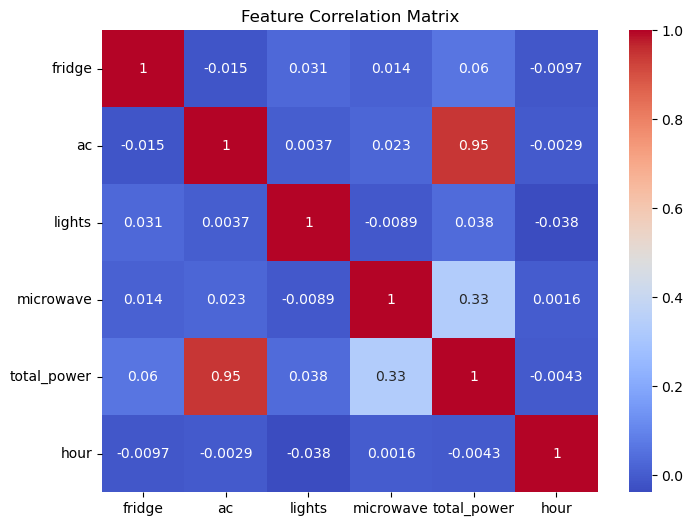

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()